**Tim Pengembang:**

Ahmad Nidzomunnashil - NIM 607012400122

Vikry Achmad Sonjaya - NIM 607012400001

Mardini Dwi Putri - NIM 607012430015

Kelas: 48-02

**Project: Mental Health Risk Prediction**

Notebook ini melatih dan mengevaluasi tiga model klasifikasi (KNN, SVM, Decision Tree) untuk memprediksi tingkat risiko kesehatan mental (0=Rendah, 1=Sedang, 2=Tinggi).

# Load library yang dibutuhkan

In [5]:
from mpl_toolkits.axisartist.axislines import SubplotZero  # import SubplotZero untuk kebutuhan visualisasi sumbu khusus
import matplotlib.pyplot as plt  # import matplotlib untuk membuat grafik
import numpy as np  # import numpy untuk operasi numerik
import pandas as pd  # import pandas untuk membaca dan mengelola data tabel
import seaborn  # import seaborn untuk mempercantik tampilan grafik
seaborn.set(style='ticks')  # mengatur gaya tampilan grafik seaborn
import matplotlib.cm as cm  # import colormap matplotlib
from sklearn import preprocessing  # import modul preprocessing dari sklearn
from sklearn.preprocessing import MinMaxScaler  # import MinMaxScaler sebagai alternatif normalisasi data
from sklearn.preprocessing import StandardScaler  # import StandardScaler untuk standarisasi fitur
from sklearn.preprocessing import LabelEncoder  # import LabelEncoder untuk mengubah label kategorik menjadi angka
from sklearn.model_selection import train_test_split  # import fungsi untuk membagi data train dan test
from sklearn.model_selection import GridSearchCV  # import GridSearchCV untuk hyperparameter tuning
from sklearn.neighbors import KNeighborsClassifier  # import KNN Classifier
from sklearn.svm import SVC  # import Support Vector Classifier
from sklearn.tree import DecisionTreeClassifier  # import Decision Tree Classifier
from sklearn.metrics import classification_report  # import classification report untuk evaluasi
from sklearn.metrics import accuracy_score  # import fungsi accuracy
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # import fungsi confusion matrix dan visualisasinya

# Load dataset

Dataset diakses dari Google Drive (file id: `1BRSI-0XdgOpB1GUaM3lilUuFrKtRmO0f`). Sel di bawah memakai `gdown` agar dataset langsung ter-download di Colab tanpa perlu mount Drive.

In [6]:
# Download dataset dari Google Drive
import gdown  # import gdown untuk download dari Google Drive
file_id = '1JvF0t0eg2K7OtcewYpwAXILtjpd3UK78'  # ID file dataset di Google Drive
output_path = 'mental_helth_risk_dataset_1000.csv'  # nama file lokal hasil download
gdown.download(f'https://drive.google.com/uc?id={file_id}', output_path, quiet=False)  # eksekusi download

Downloading...
From: https://drive.google.com/uc?id=1JvF0t0eg2K7OtcewYpwAXILtjpd3UK78
To: /content/mental_helth_risk_dataset_1000.csv
100%|██████████| 851k/851k [00:00<00:00, 119MB/s]


'mental_helth_risk_dataset_1000.csv'

In [7]:
# Load dataset ke dalam DataFrame
df = pd.read_csv(output_path)  # membaca file CSV menjadi DataFrame
print('Shape dataset:', df.shape)  # menampilkan jumlah baris dan kolom
df.head()  # menampilkan 5 baris pertama untuk melihat isi data

Shape dataset: (10000, 25)


,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,Other,Single,Bachelor,Unemployed,8.6,2.8,9.6,7,10,...,4,8,8,3,1,0,1,1,1,1
1,47,Male,Single,Bachelor,Unemployed,4.5,2.7,3.0,10,6,...,7,4,9,3,0,0,0,0,0,0
2,56,Female,Divorced,Bachelor,Student,3.1,14.1,7.2,10,5,...,3,1,4,2,1,1,1,1,1,2
3,59,Other,Married,Bachelor,Employed,7.0,0.5,10.3,2,10,...,8,5,2,5,1,1,0,1,1,2
4,58,Male,Single,High School,Self-Employed,5.1,2.5,1.2,8,1,...,8,3,3,1,0,0,1,0,1,0


In [8]:
# Cek info kolom dan tipe data
df.info()  # menampilkan tipe data tiap kolom dan jumlah non-null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               10000 non-null  int64  
 1   gender                            10000 non-null  object 
 2   marital_status                    10000 non-null  object 
 3   education_level                   10000 non-null  object 
 4   employment_status                 10000 non-null  object 
 5   sleep_hours                       10000 non-null  float64
 6   physical_activity_hours_per_week  10000 non-null  float64
 7   screen_time_hours_per_day         10000 non-null  float64
 8   social_support_score              10000 non-null  int64  
 9   work_stress_level                 10000 non-null  int64  
 10  academic_pressure_level           10000 non-null  int64  
 11  job_satisfaction_score            10000 non-null  int64  
 12  finan

In [9]:
# Cek statistik deskriptif fitur numerik
df.describe()  # menampilkan summary statistik fitur numerik

,age,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,academic_pressure_level,job_satisfaction_score,financial_stress_level,working_hours_per_week,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,38.842600,6.513530,7.494780,6.499680,5.494700,5.518200,5.495200,5.473500,5.478400,45.129400,...,5.526100,5.523300,5.548700,5.485300,0.500700,0.500700,0.511100,0.50390,0.500100,0.766900
std,12.321867,2.021321,4.336511,3.179314,2.879583,2.852873,2.870436,2.877138,2.889389,14.735419,...,2.855159,2.877201,2.885283,2.870925,0.500025,0.500025,0.499902,0.50001,0.500025,0.693551
min,18.000000,3.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,20.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,28.000000,4.800000,3.600000,3.700000,3.000000,3.000000,3.000000,3.000000,3.000000,32.000000,...,3.000000,3.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,39.000000,6.500000,7.500000,6.500000,5.000000,6.000000,6.000000,5.000000,5.000000,45.000000,...,6.000000,6.000000,6.000000,5.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
75%,49.000000,8.300000,11.300000,9.200000,8.000000,8.000000,8.000000,8.000000,8.000000,58.000000,...,8.000000,8.000000,8.000000,8.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
max,60.000000,10.000000,15.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000,70.000000,...,10.000000,10.000000,10.000000,10.000000,1.000000,1.000000,1.000000,1.00000,1.000000,2.000000


In [10]:
# Cek missing values
print('Total missing values:', df.isnull().sum().sum())  # cek total missing value
df.isnull().sum()[df.isnull().sum() > 0]  # tampilkan kolom yang punya missing value

Total missing values: 0


,0


In [11]:
# Cek distribusi target (mental_health_risk)
print('Distribusi target:')  # judul output
print(df['mental_health_risk'].value_counts().sort_index())  # menampilkan jumlah tiap kelas
print()
print('Persentase:')  # judul output persentase
print((df['mental_health_risk'].value_counts(normalize=True) * 100).sort_index().round(2))  # menampilkan persentase tiap kelas

Distribusi target:
mental_health_risk
0    3842
1    4647
2    1511
Name: count, dtype: int64

Persentase:
mental_health_risk
0    38.42
1    46.47
2    15.11
Name: proportion, dtype: float64


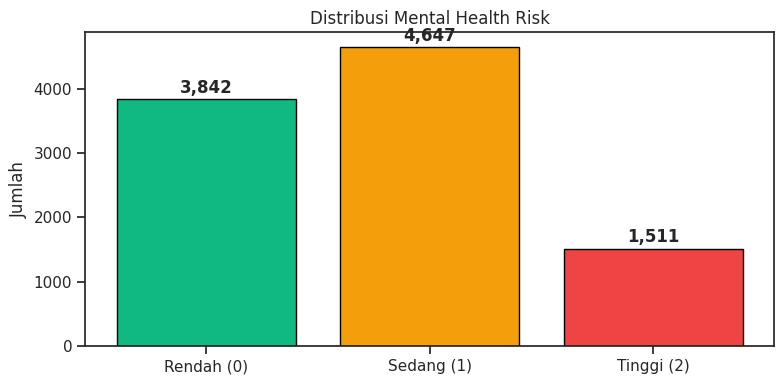

In [8]:
# Visualisasi distribusi target
plt.figure(figsize=(8, 4))  # membuat figure baru
class_counts = df['mental_health_risk'].value_counts().sort_index()  # ambil count tiap kelas
warna = ['#10b981', '#f59e0b', '#ef4444']  # warna untuk Rendah, Sedang, Tinggi
plt.bar(['Rendah (0)', 'Sedang (1)', 'Tinggi (2)'], class_counts.values, color=warna, edgecolor='black')  # plot bar chart
plt.title('Distribusi Mental Health Risk')  # judul grafik
plt.ylabel('Jumlah')  # label sumbu Y
for i, v in enumerate(class_counts.values):  # iterasi tiap bar untuk anotasi angka
    plt.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')  # tampilkan angka di atas bar
plt.tight_layout()  # rapikan layout
plt.show()  # tampilkan grafik

# Ambil feature dan label dari dataset

Fitur kategorikal (`gender`, `marital_status`, `education_level`, `employment_status`) di-encode dulu dengan `LabelEncoder` agar bisa dipakai di scikit-learn.

In [12]:
# Encode fitur kategorikal terlebih dahulu
kolom_kategorik = ['gender', 'marital_status', 'education_level', 'employment_status']  # daftar kolom kategorik
df_encoded = df.copy()  # buat salinan agar dataset asli tidak berubah
label_encoders = {}  # dictionary untuk menyimpan setiap LabelEncoder
for kolom in kolom_kategorik:  # iterasi tiap kolom kategorik
    le = LabelEncoder()  # buat objek LabelEncoder baru
    df_encoded[kolom] = le.fit_transform(df_encoded[kolom].astype(str))  # encode kolom menjadi angka
    label_encoders[kolom] = le  # simpan encoder untuk digunakan saat prediksi nanti
    print(f'{kolom}: {dict(zip(le.classes_, range(len(le.classes_))))}')  # tampilkan mapping kelas ke angka

gender: {'Female': 0, 'Male': 1, 'Other': 2}
marital_status: {'Divorced': 0, 'Married': 1, 'Single': 2}
education_level: {'Bachelor': 0, 'High School': 1, 'Master': 2, 'PhD': 3}
employment_status: {'Employed': 0, 'Self-Employed': 1, 'Student': 2, 'Unemployed': 3}


In [13]:
# Ambil fitur (X) dan label (y)
X = df_encoded.drop(columns=['mental_health_risk'])  # X = semua kolom kecuali target
y = df_encoded['mental_health_risk']  # y = kolom target

print('Shape X:', X.shape)  # menampilkan ukuran data fitur
print('Shape y:', y.shape)  # menampilkan ukuran data target
print('Jumlah fitur:', X.shape[1])  # jumlah fitur input

Shape X: (10000, 24)
Shape y: (10000,)
Jumlah fitur: 24


# Membagi dataset untuk data training (70%) dan data testing (30%)

In [14]:
# Split data menjadi 70 persen training dan 30 persen testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)  # split data dengan stratifikasi agar proporsi kelas tetap
print(X_train.shape)  # menampilkan ukuran data training
print(X_test.shape)  # menampilkan ukuran data testing

(7000, 24)
(3000, 24)


# Feature scaling

Pakai `StandardScaler` agar semua fitur berada di skala yang sama. Ini penting terutama untuk KNN dan SVM yang sensitif terhadap skala fitur.

In [15]:
# Standarisasi fitur menggunakan StandardScaler
scaler = StandardScaler()  # membuat objek StandardScaler
scaler.fit(X_train)  # mempelajari rata-rata dan standar deviasi dari data training
X_train = scaler.transform(X_train)  # mengubah data training ke skala standar
X_test = scaler.transform(X_test)  # mengubah data testing dengan skala yang sama (jangan fit ulang)

# Model 1: K-Nearest Neighbors (KNN)

## Membuat dan training classifier KNN

Memakai k=5 sebagai nilai default.

In [ ]:
# Membuat classifier KNN dengan k=5
classifier_knn = KNeighborsClassifier(n_neighbors=39)  # KNN dengan jumlah tetangga = 5

# Melakukan training
classifier_knn.fit(X_train, y_train)  # melatih KNN dengan data training

KNeighborsClassifier(n_neighbors=39)

In [ ]:
# Menghitung akurasi KNN berdasarkan data uji
akurasi_knn = classifier_knn.score(X_test, y_test)  # menghitung akurasi pada data testing
print(f'Tingkat Akurasi KNN: {akurasi_knn * 100:.2f}%')  # menampilkan akurasi dalam persen

Tingkat Akurasi KNN: 66.47%


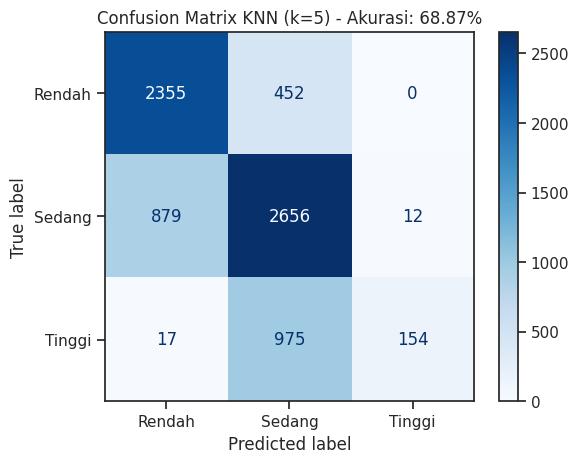

              precision    recall  f1-score   support

      Rendah       0.72      0.84      0.78      2807
      Sedang       0.65      0.75      0.70      3547
      Tinggi       0.93      0.13      0.23      1146

    accuracy                           0.69      7500
   macro avg       0.77      0.57      0.57      7500
weighted avg       0.72      0.69      0.66      7500



In [ ]:
# Confusion matrix KNN
predictions_knn = classifier_knn.predict(X_test)  # prediksi pada data testing
cm_knn = confusion_matrix(y_test, predictions_knn)  # hitung confusion matrix
disp_knn = ConfusionMatrixDisplay(cm_knn, display_labels=['Rendah', 'Sedang', 'Tinggi'])  # buat display
disp_knn.plot(cmap='Blues')  # gambar dengan warna biru
plt.title(f'Confusion Matrix KNN (k=5) - Akurasi: {akurasi_knn*100:.2f}%')  # judul grafik
plt.show()  # tampilkan

# Classification report KNN
print(classification_report(y_test, predictions_knn, target_names=['Rendah', 'Sedang', 'Tinggi']))  # report detail per kelas

## HPO untuk KNN

Mencari nilai k terbaik dengan GridSearchCV.

In [17]:
# Definisikan grid parameter untuk KNN
param_grid_knn = {  # daftar parameter yang dicoba
    'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59, 61, 63, 65, 67, 69, 71, 73, 75, 77, 79, 81, 83, 85, 87, 89, 91, 93, 95, 97, 99
],  # variasi nilai k
    'metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski'],  # variasi metric jarak
}

# GridSearchCV untuk KNN
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring='f1_weighted', cv=5, refit=True, verbose=3, n_jobs=-1)  # search parameter terbaik dengan 5-fold CV
grid_knn.fit(X_train, y_train)  # latih dengan semua kombinasi parameter

print('Parameter terbaik KNN:', grid_knn.best_params_)  # tampilkan parameter terbaik
print('Best CV score      :', round(grid_knn.best_score_, 4))  # tampilkan score CV terbaik
print('Akurasi test        :', round(accuracy_score(y_test, grid_knn.predict(X_test)), 4))  # akurasi pada test set

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Parameter terbaik KNN: {'metric': 'manhattan', 'n_neighbors': 33}
Best CV score      : 0.6659
Akurasi test        : 0.6813


# Model 2: Support Vector Machine (SVM)

## HPO untuk SVM

Memakai GridSearchCV untuk mencari kombinasi C, gamma, dan kernel terbaik.

In [18]:
# Definisikan parameter range untuk SVC
param_grid_svm = [  # daftar parameter yang akan diuji
    {'C': [1, 10, 100], 'gamma': [0.01, 0.001, 0.0001], 'kernel': ['rbf', 'linear']},  # kombinasi parameter SVC
]

# GridSearchCV untuk SVM
classifier_svm = GridSearchCV(SVC(probability=True), param_grid_svm, scoring='f1_weighted', cv=5, refit=True, verbose=3, n_jobs=-1)  # pencarian parameter terbaik
classifier_svm.fit(X_train, y_train)  # melatih model SVC untuk semua kombinasi parameter

print('Parameter terbaik SVM:', classifier_svm.best_params_)  # menampilkan parameter terbaik
print('Best estimator       :', classifier_svm.best_estimator_)  # model terbaik setelah tuning

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Parameter terbaik SVM: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best estimator       : SVC(C=10, gamma=0.01, probability=True)


In [19]:
# Prediksi data testing dengan SVM
predictions_svm = classifier_svm.predict(X_test)  # memprediksi kelas pada data testing
akurasi_svm = accuracy_score(y_test, predictions_svm)  # menghitung akurasi
print(f'Tingkat Akurasi SVM: {akurasi_svm * 100:.2f}%')  # tampilkan akurasi
print()
print(classification_report(y_test, predictions_svm, target_names=['Rendah', 'Sedang', 'Tinggi']))  # classification report

Tingkat Akurasi SVM: 79.37%

              precision    recall  f1-score   support

      Rendah       0.84      0.82      0.83      1153
      Sedang       0.76      0.81      0.78      1394
      Tinggi       0.77      0.67      0.72       453

    accuracy                           0.79      3000
   macro avg       0.79      0.77      0.78      3000
weighted avg       0.79      0.79      0.79      3000



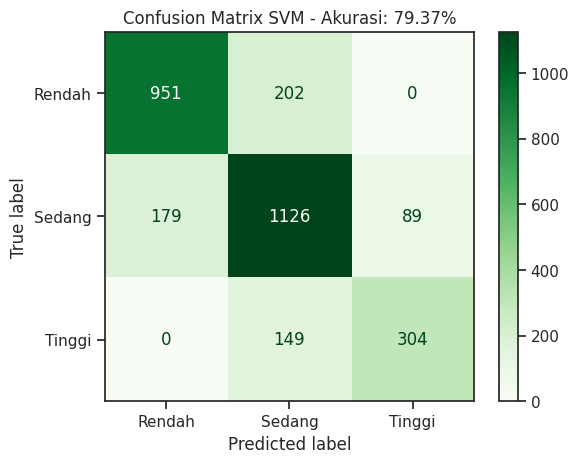

In [20]:
# Confusion matrix SVM
cm_svm = confusion_matrix(y_test, predictions_svm, labels=classifier_svm.classes_)  # hitung confusion matrix
disp_svm = ConfusionMatrixDisplay(cm_svm, display_labels=['Rendah', 'Sedang', 'Tinggi'])  # buat display
disp_svm.plot(cmap='Greens')  # gambar dengan warna hijau
plt.title(f'Confusion Matrix SVM - Akurasi: {akurasi_svm*100:.2f}%')  # judul grafik
plt.show()  # tampilkan

# Model 3: Decision Tree

## HPO untuk Decision Tree

Mencari kombinasi `max_depth`, `min_samples_split`, dan `criterion` terbaik.

In [21]:
# Definisikan grid parameter untuk Decision Tree
param_grid_dt = {  # daftar parameter yang dicoba
    'criterion': ['gini', 'entropy'],  # kriteria pembagian node
    'max_depth': [5, 10, 15, None],  # kedalaman maksimum tree
    'min_samples_split': [2, 5, 10],  # jumlah minimum sample untuk split node
    'min_samples_leaf': [1, 2, 5],  # jumlah minimum sample di setiap leaf
}

# GridSearchCV untuk Decision Tree
classifier_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, scoring='f1_weighted', cv=5, refit=True, verbose=1, n_jobs=-1)  # cari parameter terbaik
classifier_dt.fit(X_train, y_train)  # latih dengan semua kombinasi

print('Parameter terbaik DT:', classifier_dt.best_params_)  # parameter terbaik
print('Best estimator      :', classifier_dt.best_estimator_)  # model terbaik

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Parameter terbaik DT: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best estimator      : DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=2,
                       random_state=42)


In [22]:
# Prediksi data testing dengan Decision Tree
predictions_dt = classifier_dt.predict(X_test)  # prediksi kelas
akurasi_dt = accuracy_score(y_test, predictions_dt)  # akurasi
print(f'Tingkat Akurasi DT: {akurasi_dt * 100:.2f}%')  # tampilkan akurasi
print()
print(classification_report(y_test, predictions_dt, target_names=['Rendah', 'Sedang', 'Tinggi']))  # classification report

Tingkat Akurasi DT: 98.27%

              precision    recall  f1-score   support

      Rendah       0.99      1.00      1.00      1153
      Sedang       0.98      0.98      0.98      1394
      Tinggi       0.96      0.95      0.95       453

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



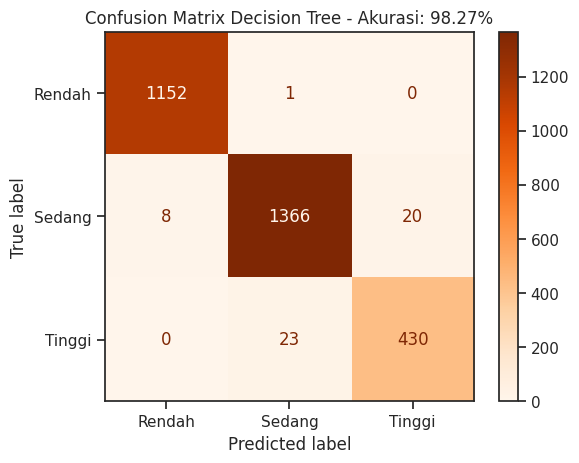

In [23]:
# Confusion matrix Decision Tree
cm_dt = confusion_matrix(y_test, predictions_dt, labels=classifier_dt.classes_)  # hitung confusion matrix
disp_dt = ConfusionMatrixDisplay(cm_dt, display_labels=['Rendah', 'Sedang', 'Tinggi'])  # buat display
disp_dt.plot(cmap='Oranges')  # gambar dengan warna oranye
plt.title(f'Confusion Matrix Decision Tree - Akurasi: {akurasi_dt*100:.2f}%')  # judul grafik
plt.show()  # tampilkan

# Visualisasi Decision Tree (top 3 levels)

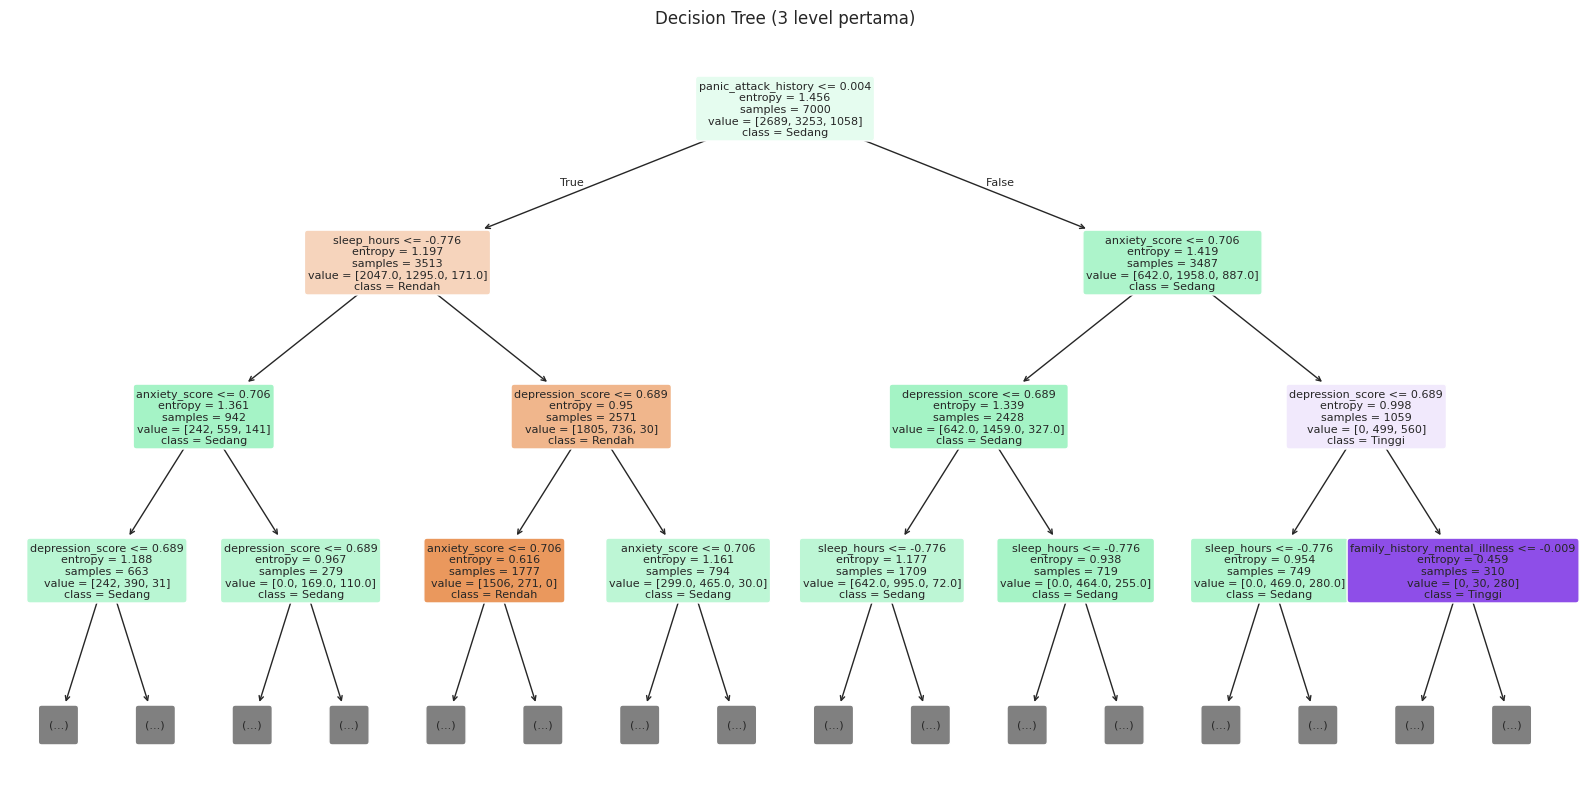

In [24]:
# Visualisasikan struktur Decision Tree (terbatas 3 level untuk keterbacaan)
from sklearn.tree import plot_tree  # import fungsi plot tree
plt.figure(figsize=(20, 10))  # ukuran figure besar untuk keterbacaan
plot_tree(  # gambar pohon keputusan
    classifier_dt.best_estimator_,  # model DT terbaik dari GridSearchCV
    max_depth=3,  # batasi visualisasi 3 level pertama
    feature_names=X.columns.tolist(),  # nama-nama fitur
    class_names=['Rendah', 'Sedang', 'Tinggi'],  # nama kelas
    filled=True,  # warnai node berdasarkan kelas mayoritas
    rounded=True,  # bentuk node bulat
    fontsize=8  # ukuran font
)
plt.title('Decision Tree (3 level pertama)')  # judul grafik
plt.show()  # tampilkan

# Perbandingan Ketiga Model

        Model  Akurasi
          KNN 0.681333
          SVM 0.793667
Decision Tree 0.982667



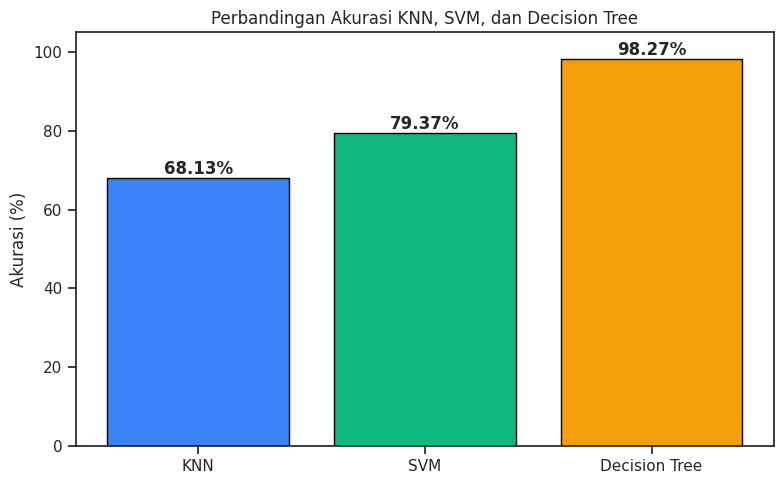

In [25]:
# Buat tabel perbandingan akurasi ketiga model
hasil_perbandingan = pd.DataFrame({  # buat DataFrame perbandingan
    'Model': ['KNN', 'SVM', 'Decision Tree'],  # nama model
    'Akurasi': [  # akurasi tiap model
        accuracy_score(y_test, grid_knn.predict(X_test)),  # akurasi KNN setelah tuning
        akurasi_svm,  # akurasi SVM setelah tuning
        akurasi_dt,  # akurasi DT setelah tuning
    ],
})

# Tampilkan tabel
print(hasil_perbandingan.to_string(index=False))  # cetak tanpa index
print()

# Visualisasi bar chart perbandingan
plt.figure(figsize=(8, 5))  # ukuran figure
warna = ['#3b82f6', '#10b981', '#f59e0b']  # warna tiap model
plt.bar(hasil_perbandingan['Model'], hasil_perbandingan['Akurasi'] * 100, color=warna, edgecolor='black')  # bar chart
for i, v in enumerate(hasil_perbandingan['Akurasi']):  # anotasi angka di atas bar
    plt.text(i, v * 100 + 1, f'{v*100:.2f}%', ha='center', fontweight='bold')  # tampilkan persen
plt.ylabel('Akurasi (%)')  # label Y
plt.title('Perbandingan Akurasi KNN, SVM, dan Decision Tree')  # judul
plt.ylim([0, 105])  # batas sumbu Y
plt.tight_layout()  # rapikan layout
plt.show()  # tampilkan

# Ensemble: Majority Voting

Mengkombinasikan prediksi dari ketiga model. Jika ketiganya berbeda, dipilih yang confidence tertinggi sebagai tiebreaker.

In [26]:
from collections import Counter  # import Counter untuk hitung suara mayoritas

# Fungsi majority voting dengan tiebreaker confidence tertinggi
def majority_voting(prediksi_list, confidence_list):  # input: list prediksi & list confidence
    counter = Counter(prediksi_list)  # hitung tiap prediksi muncul berapa kali
    suara_terbanyak = max(counter.values())  # jumlah suara mayoritas
    kandidat = [p for p, c in counter.items() if c == suara_terbanyak]  # cari kandidat dengan suara terbanyak
    if len(kandidat) == 1:  # jika hanya 1 kandidat, langsung return
        return kandidat[0]
    # Tiebreaker: pilih kandidat dengan confidence tertinggi
    best_pred, best_conf = kandidat[0], -1  # inisialisasi
    for p, c in zip(prediksi_list, confidence_list):  # iterasi semua prediksi
        if p in kandidat and c > best_conf:  # jika kandidat & confidence lebih tinggi
            best_pred, best_conf = p, c  # update best
    return best_pred  # return prediksi final

# Hitung prediksi ensemble untuk seluruh test set
ensemble_predictions = []  # list untuk menyimpan hasil ensemble
for i in range(len(X_test)):  # iterasi setiap data testing
    sample = X_test[i:i+1]  # ambil 1 sample
    pred_knn = int(grid_knn.predict(sample)[0])  # prediksi KNN
    pred_svm = int(classifier_svm.predict(sample)[0])  # prediksi SVM
    pred_dt = int(classifier_dt.predict(sample)[0])  # prediksi DT

    # Confidence dari predict_proba
    conf_knn = float(grid_knn.predict_proba(sample)[0].max())  # confidence KNN
    conf_svm = float(classifier_svm.predict_proba(sample)[0].max())  # confidence SVM
    conf_dt = float(classifier_dt.predict_proba(sample)[0].max())  # confidence DT

    final = majority_voting([pred_knn, pred_svm, pred_dt], [conf_knn, conf_svm, conf_dt])  # voting
    ensemble_predictions.append(final)  # simpan hasil

ensemble_predictions = np.array(ensemble_predictions)  # ubah ke numpy array
akurasi_ensemble = accuracy_score(y_test, ensemble_predictions)  # akurasi ensemble
print(f'Akurasi Ensemble (Majority Voting): {akurasi_ensemble * 100:.2f}%')  # tampilkan akurasi

Akurasi Ensemble (Majority Voting): 86.30%


In [27]:
# Tabel perbandingan final
hasil_final = pd.DataFrame({  # DataFrame perbandingan termasuk ensemble
    'Model': ['KNN', 'SVM', 'Decision Tree', 'Ensemble (Majority Vote)'],  # nama model
    'Akurasi (%)': [  # akurasi dalam persen
        round(accuracy_score(y_test, grid_knn.predict(X_test)) * 100, 2),
        round(akurasi_svm * 100, 2),
        round(akurasi_dt * 100, 2),
        round(akurasi_ensemble * 100, 2),
    ],
})
print(hasil_final.to_string(index=False))  # cetak tabel

                   Model  Akurasi (%)
                     KNN        68.13
                     SVM        79.37
           Decision Tree        98.27
Ensemble (Majority Vote)        86.30


# Test Prediksi pada Sample Baru

Mencoba prediksi pada profil sample. Silakan ubah angka pada dictionary `sample_baru` sesuai keinginan.

In [28]:
# Profil sample: mahasiswa muda dengan tekanan akademik tinggi
sample_baru = {  # dictionary input fitur
    'age': 20, 'gender': 'Male', 'marital_status': 'Single',
    'education_level': 'Bachelor', 'employment_status': 'Student',
    'sleep_hours': 5.0, 'physical_activity_hours_per_week': 1.5,
    'screen_time_hours_per_day': 10.0, 'social_support_score': 3,
    'work_stress_level': 6, 'academic_pressure_level': 9,
    'job_satisfaction_score': 4, 'financial_stress_level': 8,
    'working_hours_per_week': 50,
    'anxiety_score': 8, 'depression_score': 7, 'stress_level': 8,
    'mood_swings_frequency': 7, 'concentration_difficulty_level': 7,
    'panic_attack_history': 1, 'family_history_mental_illness': 1,
    'previous_mental_health_diagnosis': 0, 'therapy_history': 0,
    'substance_use': 0,
}

# Preprocess sample (encode kategorik + scaling)
nama_fitur = X.columns.tolist()  # urutan nama fitur seperti saat training
baris_sample = []  # list untuk menampung nilai yang sudah di-encode
for kolom in nama_fitur:  # iterasi tiap fitur sesuai urutan
    nilai = sample_baru[kolom]  # ambil nilai dari sample
    if kolom in kolom_kategorik:  # jika kolom kategorik
        baris_sample.append(int(label_encoders[kolom].transform([str(nilai)])[0]))  # encode pakai LabelEncoder yang tersimpan
    else:
        baris_sample.append(float(nilai))  # langsung pakai nilai numerik
sample_arr = scaler.transform([baris_sample])  # scaling pakai scaler yang tersimpan

# Prediksi dengan ketiga model
label_map = {0: 'Rendah', 1: 'Sedang', 2: 'Tinggi'}  # mapping kelas ke label

pred_knn = int(grid_knn.predict(sample_arr)[0])  # prediksi KNN
pred_svm = int(classifier_svm.predict(sample_arr)[0])  # prediksi SVM
pred_dt = int(classifier_dt.predict(sample_arr)[0])  # prediksi DT

conf_knn = float(grid_knn.predict_proba(sample_arr)[0].max())  # confidence KNN
conf_svm = float(classifier_svm.predict_proba(sample_arr)[0].max())  # confidence SVM
conf_dt = float(classifier_dt.predict_proba(sample_arr)[0].max())  # confidence DT

print('Prediksi tiap model:')  # judul output
print(f'  KNN          : {label_map[pred_knn]:8s} (confidence: {conf_knn*100:.2f}%)')  # KNN
print(f'  SVM          : {label_map[pred_svm]:8s} (confidence: {conf_svm*100:.2f}%)')  # SVM
print(f'  Decision Tree: {label_map[pred_dt]:8s} (confidence: {conf_dt*100:.2f}%)')  # DT

final_pred = majority_voting([pred_knn, pred_svm, pred_dt], [conf_knn, conf_svm, conf_dt])  # majority vote
print(f'\nFINAL (Majority Voting): {label_map[final_pred]}')  # tampilkan hasil akhir

Prediksi tiap model:
  KNN          : Tinggi   (confidence: 54.55%)
  SVM          : Tinggi   (confidence: 90.64%)
  Decision Tree: Tinggi   (confidence: 100.00%)

FINAL (Majority Voting): Tinggi


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Save Model (opsional)

Sel ini menyimpan ketiga model + scaler + encoders sebagai file `.pkl` agar bisa dipakai di sistem produksi (misal Laravel app).

In [ ]:
import pickle  # import pickle untuk serialisasi model

# Daftar artifact yang akan disimpan
def simpan(obj, nama_file):  # helper untuk save pakai pickle
    with open(nama_file, 'wb') as f:  # buka file mode write binary
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)  # serialisasi dengan protocol tertinggi
    return nama_file  # return nama file untuk konfirmasi

artifacts = []  # list nama file yang dibuat
artifacts.append(simpan(grid_knn.best_estimator_, 'knn_model.pkl'))  # KNN terbaik
artifacts.append(simpan(classifier_svm.best_estimator_, 'svm_model.pkl'))  # SVM terbaik
artifacts.append(simpan(classifier_dt.best_estimator_, 'dt_model.pkl'))  # DT terbaik
artifacts.append(simpan(scaler, 'scaler.pkl'))  # scaler
artifacts.append(simpan(label_encoders, 'encoders.pkl'))  # encoder dictionary
artifacts.append(simpan(nama_fitur, 'feature_names.pkl'))  # urutan nama fitur

print('File yang dihasilkan:')  # judul
for a in artifacts:  # iterasi
    print(f'  - {a}')  # tampilkan nama file

# Download otomatis di Colab
try:
    from google.colab import files  # import modul download Colab
    for a in artifacts:  # iterasi tiap file
        files.download(a)  # trigger download ke laptop user
except Exception:
    print('\n(Bukan di Colab - file tersimpan di working directory)')  # fallback kalau bukan di Colab

File yang dihasilkan:
  - knn_model.pkl
  - svm_model.pkl
  - dt_model.pkl
  - scaler.pkl
  - encoders.pkl
  - feature_names.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Selesai

Notebook ini telah:

1. Memuat dataset Mental Health Risk dari Google Drive
2. Melakukan EDA dasar (info, statistik, distribusi target)
3. Encoding fitur kategorikal dan feature scaling
4. Melatih dan tuning **3 model klasifikasi** (KNN, SVM, Decision Tree)
5. Mengevaluasi dengan accuracy, classification report, dan confusion matrix
6. Membandingkan performa ketiga model + ensemble majority voting
7. Mencoba prediksi pada profil sample
8. Menyimpan model (opsional)

**Disclaimer:** Hasil prediksi sistem ini bersifat edukatif dan referensi, bukan diagnosis medis.